In [1]:
from astropy.io import fits
import numpy as np
import os
import matplotlib.pyplot as plt
from specula.mmlib.utils import get_pupil_mask, shift_image, get_frame_pupil_centers


sky_pyr_mask = get_pupil_mask(npix=240,filepath='/raid1/mmenessini/calibration/EKARUS/pupils/pyr_pupdata_onsky.fits')[60:180,60:180]
pyr_mask = get_pupil_mask(npix=240,filepath='/raid1/mmenessini/calibration/EKARUS/pupils/pyr_pupdata_onbench.fits')[60:180,60:180]

2026-08-17 13:25:10,552 [INFO]: [specula]: Cupy import successfull. Installed version is: 13.3.0
2026-08-17 13:25:10,686 [INFO]: [specula]: Default device is GPU number 0


In [2]:
def get_meas_frame(im,idx):
    imframe = im[:,idx].reshape([240,240])
    imstd = np.std(im,axis=1).reshape([240,240])
    ref_centers = get_frame_pupil_centers(imstd)
    savg_center = np.mean(ref_centers,axis=0)
    hsize = 120
    frimg = shift_image(imframe, shift=120-savg_center[1], axis=0)
    frimg = shift_image(frimg, shift=120-savg_center[0], axis=1)
    return frimg[60:180,60:180]

def get_sim_frame(im,idx,pupids):
    npix = 240
    fimg_bench = np.zeros([npix,npix])
    rtot = 0
    for k in range(4):
        valid_ids = pupids[:,k] != -1
        len_ids = np.sum(valid_ids)
        np.put(fimg_bench, pupids[valid_ids,k], im[rtot:rtot+len_ids,idx])
        rtot += len_ids
    bench2d = fimg_bench.reshape([npix,npix])
    return bench2d[60:180,60:180]

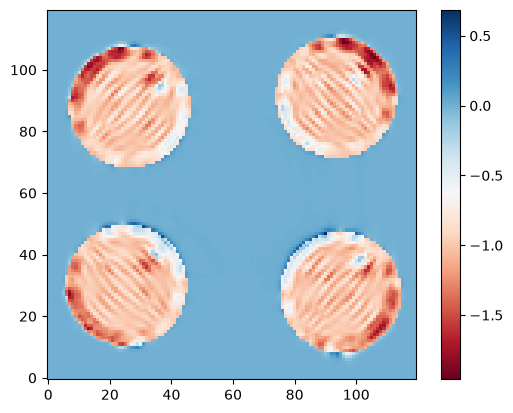

In [3]:
# im = fits.getdata('/raid1/mmenessini/calibration/EKARUS/data/IntMat_20260802_233704.fits')
im = fits.getdata('/raid1/mmenessini/calibration/EKARUS/data/IntMat_20260815_194918.fits') #194038 #193320
rec = np.linalg.pinv(im)

frimg = get_meas_frame(im,idx=390)

plt.figure()
plt.imshow(frimg/np.max(frimg)-pyr_mask,origin='lower',cmap='RdBu')
plt.colorbar()

In [4]:
rMod = 5
benchim = fits.getdata(f'/raid1/mmenessini/calibration/EKARUS/im/pyr{rMod:1.1f}_onbench_measIF_dm468_im.fits')
pup_hdu = fits.open('/raid1/mmenessini/calibration/EKARUS/pupils/pyr_pupdata_onbench.fits')
pup_ids_bench = pup_hdu[1].data

benchrec = np.linalg.pinv(benchim)

Text(0.5, 1.0, 'Difference')

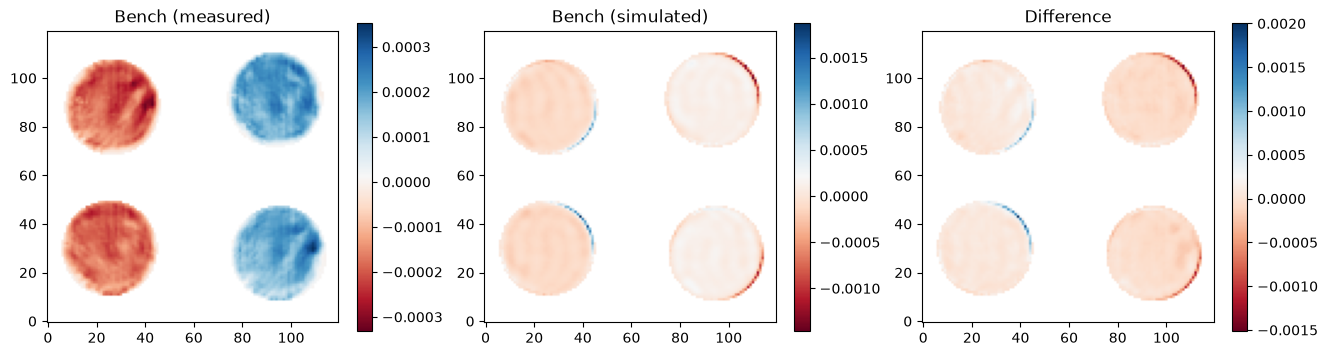

In [5]:
jdx = 0

f2d_meas = get_meas_frame(im,idx=jdx)
f2d_bench = get_sim_frame(benchim,idx=jdx,pupids=pup_ids_bench)

f2d_bench *= np.std(f2d_meas[pyr_mask])/np.std(f2d_bench[pyr_mask])

plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
plt.imshow(np.ma.masked_array(f2d_meas,mask=1-pyr_mask),origin='lower',cmap='RdBu')
plt.colorbar()
plt.title('Bench (measured)')
plt.subplot(1,3,2)
plt.imshow(np.ma.masked_array(f2d_bench,mask=1-pyr_mask),origin='lower',cmap='RdBu')
plt.colorbar()
plt.title('Bench (simulated)')
plt.subplot(1,3,3)
plt.imshow(np.ma.masked_array(f2d_bench-f2d_meas,mask=1-pyr_mask),origin='lower',cmap='RdBu')
plt.colorbar()
plt.title('Difference')